# Employee Database Deduplication

### Submitted By: Mobeen Maroof
### Registration No: Mtech-DS26013

## Objective
The purpose of this project is to clean an employee database by removing duplicate records, fixing inconsistent names, handling missing values, and preparing a clean dataset for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("employee_data.csv")

In [3]:
df.head(10)

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,Fatima Noor,HR,52000,fatima@gmail.com
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com
6,107,Ayesha Malik,IT,75000,ayesha@gmail.com
7,108,Hamza Sheikh,Finance,68000,hamza@gmail.com
8,109,Usman Raza,Sales,45000,usman@gmail.com
9,110,Zara Noor,HR,55000,zara@gmail.com


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (42, 5)


In [5]:
df.columns

Index(['EmployeeID', 'Name', 'Department', 'Salary', 'Email'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EmployeeID  42 non-null     int64 
 1   Name        42 non-null     object
 2   Department  42 non-null     object
 3   Salary      42 non-null     int64 
 4   Email       42 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.8+ KB


In [7]:
df.describe()

,EmployeeID,Salary
count,42.000000,42.000000
mean,121.500000,57023.809524
std,12.267844,10780.488462
min,101.000000,44000.000000
25%,111.250000,48250.000000
50%,121.500000,53500.000000
75%,131.750000,66875.000000
max,142.000000,81000.000000


In [8]:
df.isnull().sum()

EmployeeID    0
Name          0
Department    0
Salary        0
Email         0
dtype: int64

In [9]:
duplicates = df[df.duplicated()]
duplicates

,EmployeeID,Name,Department,Salary,Email


In [14]:
print("Complete Duplicate Rows :", df.duplicated().sum())
print("Duplicate Employee IDs  :", df.duplicated(subset=['EmployeeID']).sum())
print("Duplicate Emails        :", df.duplicated(subset=['Email']).sum())
print("Duplicate Names         :", df.duplicated(subset=['Name']).sum())
print("Duplicate Name+Dept     :", df.duplicated(subset=['Name','Department']).sum())
print("Duplicate Name+Dept+Salary :", df.duplicated(subset=['Name','Department','Salary']).sum())

Complete Duplicate Rows : 0
Duplicate Employee IDs  : 0
Duplicate Emails        : 13
Duplicate Names         : 10
Duplicate Name+Dept     : 10
Duplicate Name+Dept+Salary : 10


In [10]:
duplicates = df[df.duplicated(subset=["Name", "Email"], keep=False)]
duplicates

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,Fatima Noor,HR,52000,fatima@gmail.com
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com
8,109,Usman Raza,Sales,45000,usman@gmail.com
10,111,Ali Khan,HR,50000,ali@gmail.com
13,114,Noor Ali,Marketing,47000,noor@gmail.com
19,120,Iqra Ahmed,HR,56000,iqra@gmail.com
23,124,Rida Noor,Marketing,49000,rida@gmail.com


In [15]:
df["Name"] = df["Name"].str.strip()

In [16]:
df["Name"] = df["Name"].str.title()

In [17]:
df.head()

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,Fatima Noor,HR,52000,fatima@gmail.com


In [27]:
df = df.drop_duplicates(
    subset=['Name', 'Department', 'Salary'],
    keep='first'
)

In [28]:
df = df.drop_duplicates(subset=['Email'], keep='last')

In [29]:
print("Complete Duplicate Rows :", df.duplicated().sum())
print("Duplicate Employee IDs  :", df.duplicated(subset=['EmployeeID']).sum())
print("Duplicate Emails        :", df.duplicated(subset=['Email']).sum())
print("Duplicate Names         :", df.duplicated(subset=['Name']).sum())
print("Duplicate Name+Dept     :", df.duplicated(subset=['Name','Department']).sum())
print("Duplicate Name+Dept+Salary :", df.duplicated(subset=['Name','Department','Salary']).sum())

Complete Duplicate Rows : 0
Duplicate Employee IDs  : 0
Duplicate Emails        : 0
Duplicate Names         : 0
Duplicate Name+Dept     : 0
Duplicate Name+Dept+Salary : 0


In [30]:
print(df.shape)

(29, 5)


In [31]:
print(df.duplicated().sum())

0


In [32]:
department = df["Department"].value_counts()

department

Department
HR           9
IT           6
Finance      6
Sales        5
Marketing    3
Name: count, dtype: int64

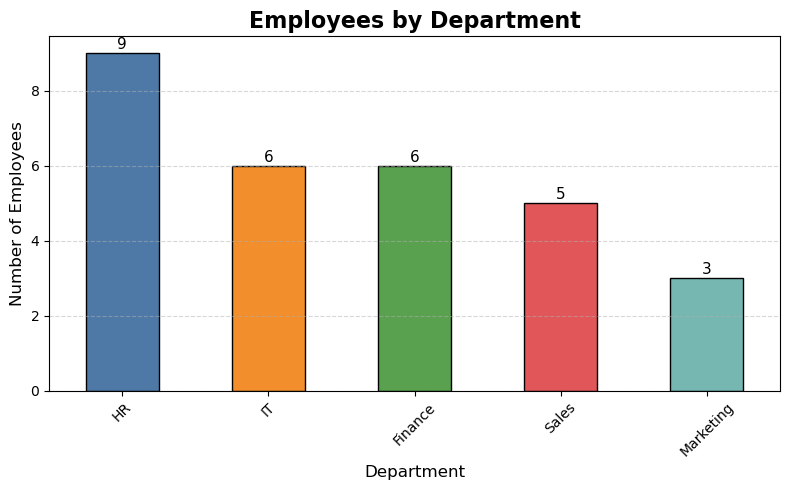

In [34]:
department.plot(
    kind="bar",
    figsize=(8,5),
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2"],
    edgecolor="black"
)
plt.title("Employees by Department", fontsize=16, fontweight="bold")
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=45)

for i, value in enumerate(department.values):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

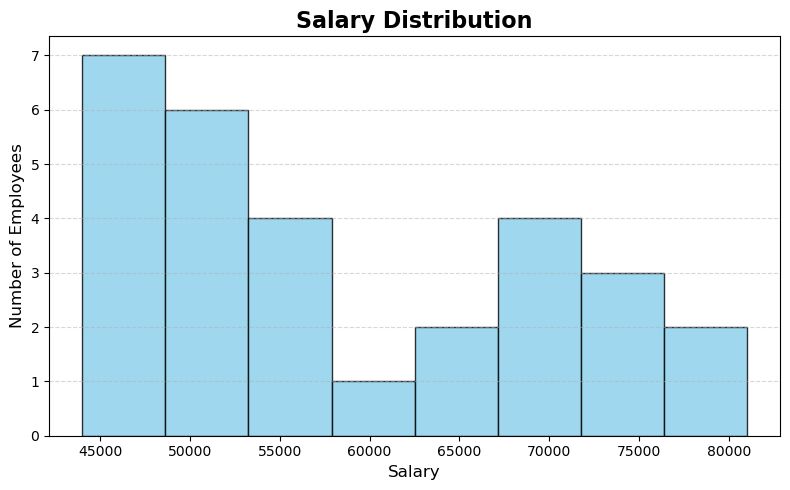

In [35]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Salary"],
    bins=8,
    color="skyblue",
    edgecolor="black",
    alpha=0.8
)
plt.title("Salary Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Salary", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

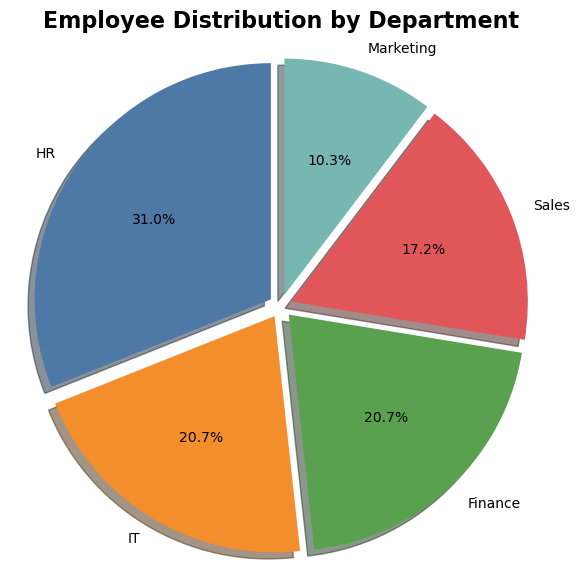

In [36]:
department = df["Department"].value_counts()
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2"]
plt.figure(figsize=(7,7))

plt.pie(
    department,
    labels=department.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    shadow=True,
    explode=[0.05]*len(department)
)
plt.title("Employee Distribution by Department", fontsize=16, fontweight="bold")
plt.axis("equal")
plt.show()

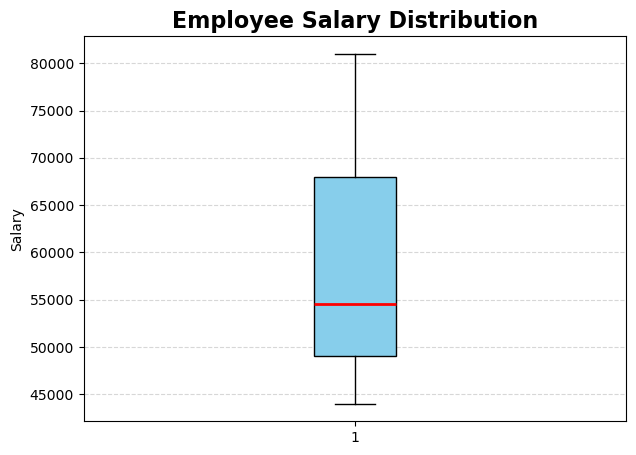

In [37]:
plt.figure(figsize=(7,5))

plt.boxplot(
    df["Salary"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Employee Salary Distribution", fontsize=16, fontweight="bold")
plt.ylabel("Salary")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

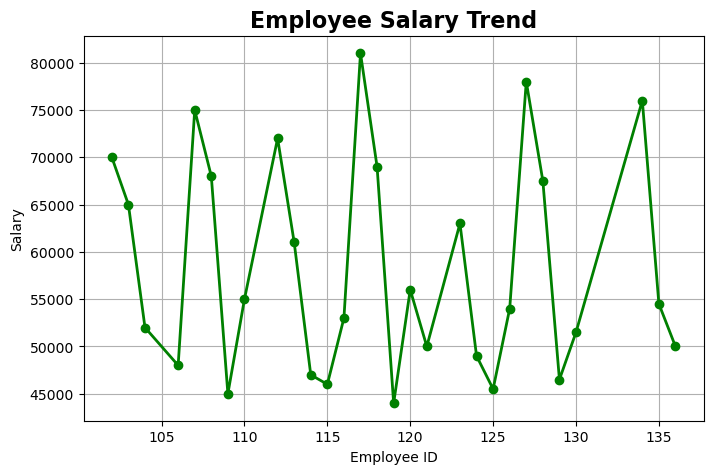

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    df["EmployeeID"],
    df["Salary"],
    marker="o",
    color="green",
    linewidth=2
)

plt.title("Employee Salary Trend", fontsize=16, fontweight="bold")
plt.xlabel("Employee ID")
plt.ylabel("Salary")

plt.grid(True)

plt.show()

In [40]:
print("Average Salary =", df["Salary"].mean())

Average Salary = 58362.06896551724


In [41]:
print("Highest Salary =", df["Salary"].max())

Highest Salary = 81000


In [42]:
print("Lowest Salary =", df["Salary"].min())

Lowest Salary = 44000


In [43]:
df[df["Department"]=="IT"]

,EmployeeID,Name,Department,Salary,Email
1,102,Sara Ahmed,IT,70000,sara@gmail.com
6,107,Ayesha Malik,IT,75000,ayesha@gmail.com
11,112,Hina Akram,IT,72000,hina@gmail.com
16,117,Danish Ali,IT,81000,danish@gmail.com
26,127,Huzaifa Khan,IT,78000,huzaifa@gmail.com
33,134,Zain Abbas,IT,76000,zain@gmail.com


In [44]:
df[df["Department"]=="HR"]

,EmployeeID,Name,Department,Salary,Email
3,104,Fatima Noor,HR,52000,fatima@gmail.com
9,110,Zara Noor,HR,55000,zara@gmail.com
15,116,Mariam Iqbal,HR,53000,mariam@gmail.com
19,120,Iqra Ahmed,HR,56000,iqra@gmail.com
20,121,Ali Khan,HR,50000,ali@gmail.com
25,126,Mahnoor Ali,HR,54000,mahnoor@gmail.com
29,130,Aiman Khan,HR,51500,aiman@gmail.com
34,135,Eman Fatima,HR,54500,eman@gmail.com
35,136,Sana Ali,HR,50000,sana@gmail.com


In [45]:
df[df["Department"]=="Finance"]

,EmployeeID,Name,Department,Salary,Email
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
7,108,Hamza Sheikh,Finance,68000,hamza@gmail.com
12,113,Omar Farooq,Finance,61000,omar@gmail.com
17,118,Areeba Khan,Finance,69000,areeba@gmail.com
22,123,Kamran Shah,Finance,63000,kamran@gmail.com
27,128,Laiba Iqbal,Finance,67500,laiba@gmail.com


In [46]:
df.to_csv("clean_employee_data.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
